<a href="https://colab.research.google.com/github/10dimensions/gnc-toolbox/blob/main/extended_kalman_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# =========================================================================
# 1. Non-Linear System and Measurement Models
# =========================================================================

def state_transition(x, dt):
    """
    Non-linear state transition function f(x).
    In this specific example, the dynamics are linear (constant velocity),
    but we wrap it in a function to maintain the EKF structure.
    """
    px, vx, py, vy = x
    return np.array([
        px + vx * dt,
        vx,
        py + vy * dt,
        vy
    ])

In [3]:
def F_jacobian(x, dt):
    """
    Jacobian of the state transition function (F matrix).
    Since our dynamics are linear, this matrix is constant.
    """
    return np.array([
        [1, dt, 0,  0],
        [0,  1, 0,  0],
        [0,  0, 1, dt],
        [0,  0, 0,  1]
    ])

In [4]:
def measurement_model(x):
    """
    Non-linear measurement function h(x).
    Radar measures Range (r) and Bearing (theta).
    """
    px, vx, py, vy = x
    r = np.sqrt(px**2 + py**2)
    theta = np.arctan2(py, px)
    return np.array([r, theta])

In [5]:
def H_jacobian(x):
    """
    Jacobian of the measurement function (H matrix).
    This is the core of the EKF! It linearizes the radar model
    around the current state estimate.
    """
    px, vx, py, vy = x
    r = np.sqrt(px**2 + py**2)

    # Defensive programming: prevent division by zero if spacecraft is at origin
    if r < 1e-6:
        return np.zeros((2, 4))

    r2 = r**2

    # Derivatives of Range and Bearing with respect to [px, vx, py, vy]
    H = np.array([
        [px / r,   0, py / r,   0],       # d(Range)/d(state)
        [-py / r2, 0, px / r2,  0]        # d(Bearing)/d(state)
    ])
    return H

In [6]:
# =========================================================================
# 2. EKF Predict and Update Steps
# =========================================================================

def ekf_predict(x, P, F, Q):
    """EKF Time Update (Predict)"""
    x_pred = F @ x
    P_pred = F @ P @ F.T + Q
    return x_pred, P_pred

In [7]:
def ekf_update(x_pred, P_pred, z, H, R):
    """EKF Measurement Update (Correct)"""
    # 1. Innovation (Residual)
    # Note: For angles, we must wrap the innovation to [-pi, pi]
    y = z - measurement_model(x_pred)
    y[1] = np.arctan2(np.sin(y[1]), np.cos(y[1])) # Wrap bearing angle

    # 2. Innovation Covariance
    S = H @ P_pred @ H.T + R

    # 3. Kalman Gain
    K = P_pred @ H.T @ np.linalg.inv(S)

    # 4. State Update (ADDITIVE - This is why it fails for quaternions!)
    x_upd = x_pred + K @ y

    # 5. Covariance Update (Joseph form for numerical stability)
    I_KH = np.eye(len(x_pred)) - K @ H
    P_upd = I_KH @ P_pred @ I_KH.T + K @ R @ K.T

    return x_upd, P_upd

In [8]:
# =========================================================================
# 3. Main Simulation and Execution
# =========================================================================
print("--- Standard Extended Kalman Filter (Radar Tracking) ---\n")

# Simulation parameters
dt = 0.1
t_total = 20.0
t = np.arange(0, t_total, dt)
n_steps = len(t)

# True initial state: [px, vx, py, vy]
x_true = np.array([100.0, 5.0, 50.0, -2.0])

# Process Noise (Q) and Measurement Noise (R)
q_var = 0.1
Q = np.diag([q_var*dt**4/4, q_var*dt**2, q_var*dt**4/4, q_var*dt**2])

r_var = 5.0**2       # Range noise variance (m^2)
theta_var = (0.02)**2 # Bearing noise variance (rad^2)
R = np.diag([r_var, theta_var])

# Initialize EKF
x_est = np.array([105.0, 0.0, 45.0, 0.0]) # Bad initial guess
P = np.diag([100.0, 100.0, 100.0, 100.0]) # High initial uncertainty

# Storage for plotting
x_hist = np.zeros((4, n_steps))
x_true_hist = np.zeros((4, n_steps))
z_hist = np.zeros((2, n_steps))

np.random.seed(42)


--- Standard Extended Kalman Filter (Radar Tracking) ---



In [10]:
 print("Running EKF simulation...")

 P_hist = np.zeros((4, 4, len(t)))

for i in range(n_steps):
    # --- True Dynamics & Measurements ---
    if i > 0:
        x_true = state_transition(x_true, dt)

    # Generate noisy radar measurements
    z_true = measurement_model(x_true)
    z_meas = z_true + np.random.normal(0, np.sqrt(np.diag(R)))
    z_hist[:, i] = z_meas

    # --- EKF Loop ---
    F = F_jacobian(x_est, dt)
    H = H_jacobian(x_est)

    x_est, P = ekf_predict(x_est, P, F, Q)
    x_est, P = ekf_update(x_est, P, z_meas, H, R)

    x_hist[:, i] = x_est
    x_true_hist[:, i] = x_true

    P_hist[:, :, i] = P



Running EKF simulation...


Plot saved as 'ekf_radar_tracking.png'


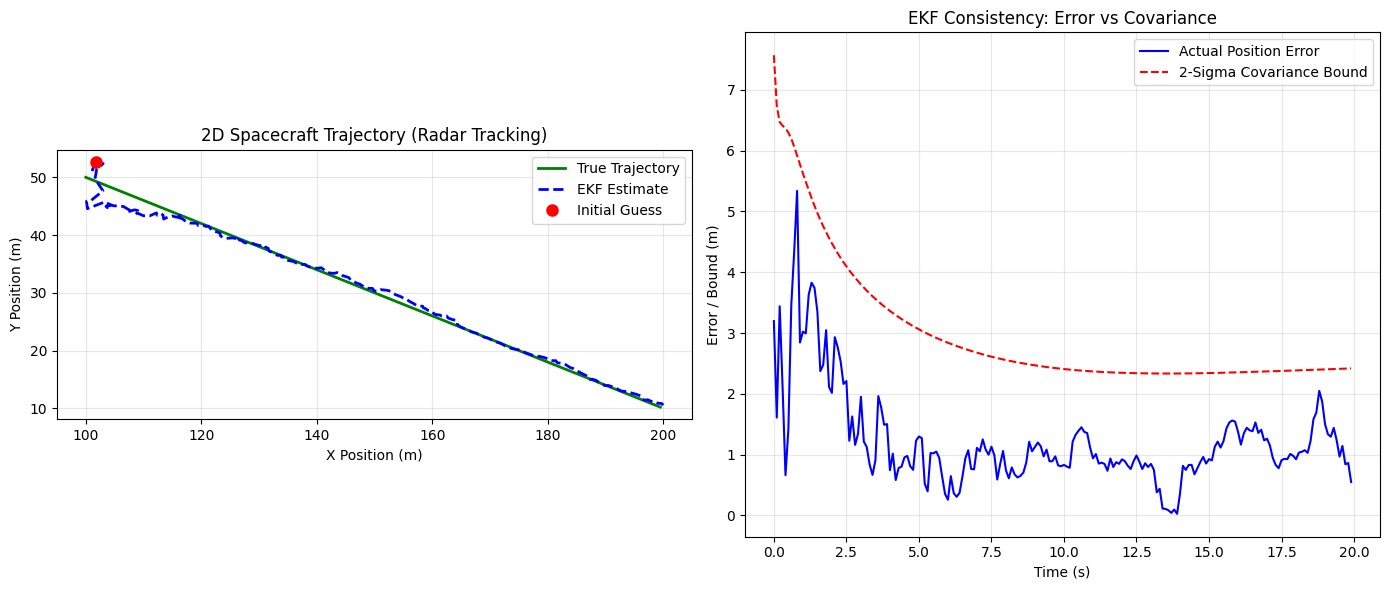


Final Position RMSE: 1.45 meters
-> The EKF successfully fused the non-linear radar data to track the spacecraft!


In [11]:
# =========================================================================
# 4. Visualization
# =========================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: 2D Trajectory
ax1.plot(x_true_hist[0, :], x_true_hist[2, :], 'g-', linewidth=2, label='True Trajectory')
ax1.plot(x_hist[0, :], x_hist[2, :], 'b--', linewidth=2, label='EKF Estimate')
ax1.plot(x_hist[0, 0], x_hist[2, 0], 'ro', markersize=8, label='Initial Guess')
ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.set_title('2D Spacecraft Trajectory (Radar Tracking)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Plot 2: Position Error and Covariance Bounds
pos_error = np.sqrt((x_hist[0, :] - x_true_hist[0, :])**2 +
                    (x_hist[2, :] - x_true_hist[2, :])**2)
# pos_std = np.sqrt(P[0, 0] + P[2, 2]) # Simplified combined std dev
pos_std = np.sqrt(P_hist[0, 0, :] + P_hist[2, 2, :])

ax2.plot(t, pos_error, 'b-', label='Actual Position Error')
ax2.plot(t, 2 * pos_std, 'r--', label='2-Sigma Covariance Bound')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Error / Bound (m)')
ax2.set_title('EKF Consistency: Error vs Covariance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ekf_radar_tracking.png', dpi=150)
print("Plot saved as 'ekf_radar_tracking.png'")
plt.show()

# Final RMSE calculation
rmse = np.sqrt(np.mean(pos_error**2))
print(f"\nFinal Position RMSE: {rmse:.2f} meters")
print("-> The EKF successfully fused the non-linear radar data to track the spacecraft!")